# Install Requirement

In [ ]:
# Installation of the retina-face package.
!pip install retina-face

# Import libraries and Mount the Drive

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import Library
import cv2
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from google.colab.output import eval_js
from retinaface import RetinaFace
from IPython.display import display, Javascript, Image
from base64 import b64decode, b64encode
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# File Paths

In [ ]:
# Model path
model_path = '/content/drive/MyDrive/Algonquin/Machine Vision/Project/emotion_model.h5'
# Check model directory
os.path.exists(model_path)


True

# Capture photo from Camera And using retina to setect the face and detect the Emotion

In [ ]:
# load model
model= load_model(model_path)

In [ ]:
# Classes 7 emotional states
class_names = ['Angry', 'Disgusted', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

In [ ]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # Get photo data
  data = eval_js('takePhoto({})'.format(quality))

  # Convert JavaScript image data to OpenCV format
  img = js_to_image(data)

  # Detect faces using RetinaFace
  faces = RetinaFace.detect_faces(img)

  # Extract aligned faces
  face_alignments = RetinaFace.extract_faces(img_path=img, align=True)

  # Draw bounding boxes and detect emotions
  for (key, face) in zip(faces.keys(), face_alignments):
      identity = faces[key]
      x, y, w, h = identity["facial_area"]

      # Preprocess face image for emotion detection
      face_image = cv2.resize(face, (48, 48))
      face_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)
      face_image = image.img_to_array(face_image)
      face_image = np.expand_dims(face_image, axis=0)
      face_image = np.vstack([face_image])

      # Predict emotion
      emotion_pred = model.predict(face_image)
      emotion_label = np.argmax(emotion_pred)  # Assuming softmax output

      # Map label index to emotion categories
      emotion_dict = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Neutral', 5: 'Sad', 6: 'Surprise'}
      predicted_emotion = emotion_dict.get(emotion_label, "Unknown")

      # Draw bounding box
      img = cv2.rectangle(img, (x, y), (w, h), (255, 0, 0), 2)

      # Add emotion label above the box
      font = cv2.FONT_HERSHEY_SIMPLEX
      font_scale = 0.6
      font_thickness = 2
      text_x = x
      text_y = y - 10 if y - 10 > 10 else y + 20

      cv2.putText(img, predicted_emotion, (text_x, text_y), font, font_scale, (255, 0, 0), font_thickness, cv2.LINE_AA)

  # Save image
  cv2.imwrite(filename, img)

  return filename

<IPython.core.display.Javascript object>

1/1 [==============================] - 0s 17ms/step
Saved to photo.jpg


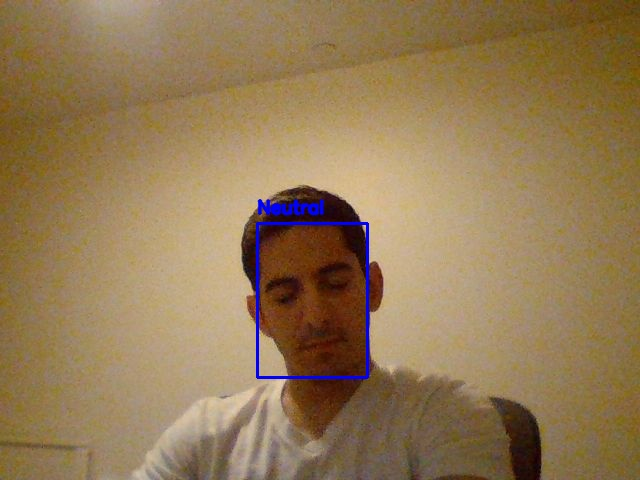

In [ ]:
try:
  filename = take_photo('photo.jpg')
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

# Emotion Detection Net

## Download dataset

In [ ]:
##Takes Alot of time
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("msambare/fer2013")

# print("Path to dataset files:", path)

100%|██████████| 60.3M/60.3M [00:00<00:00, 175MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [ ]:
# read zip file and uzip it
!unzip '/content/drive/MyDrive/Algonquin/Machine Vision/Project/archive.zip' -d '/content/drive/MyDrive/Algonquin/Machine Vision/Project/'

## Mount Drive and import libraries

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libraries
import numpy as np
import tensorflow as tf
import cv2
import os
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense, GlobalAveragePooling2D

## Count data

In [ ]:
# Count data in each class and plot it
def count_data(path, plot = True ):
  # Checking the path
  if os.path.exists(path) == False:
    print('Path does not exist')
    return
  # Create a dictionary of each class count
  emotions = os.listdir(path)
  data_count = {emotion: len(os.listdir(os.path.join(path, emotion))) for emotion in emotions}

  # Barpltot
  if plot:
    # Plot the counts
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=list(data_count.keys()), y=list(data_count.values()), color="blue")

    # Annotate bars with counts
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

    plt.xlabel("Emotions")
    plt.ylabel("Number of Images")
    plt.title("Number of Images per Emotion")
    plt.xticks(rotation=45)
    plt.show()

  return data_count

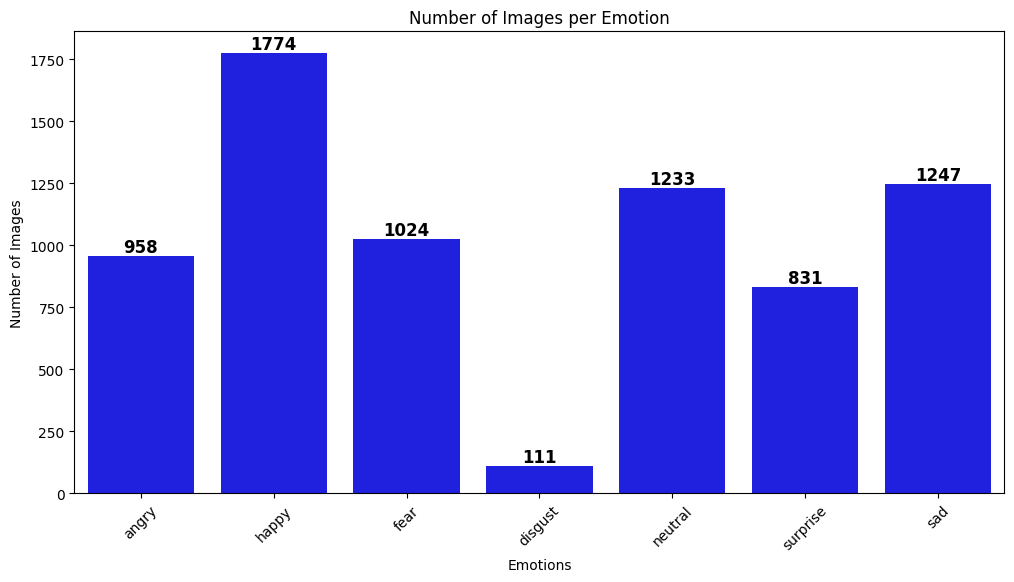

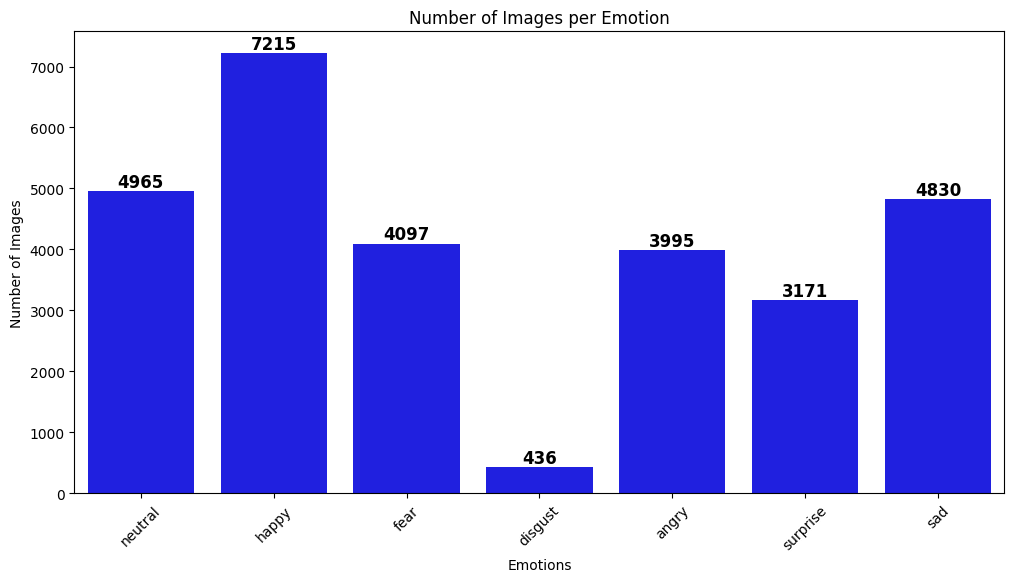

In [ ]:
path = '/content/drive/MyDrive/Algonquin/Machine Vision/Project/FER'
for fol in os.listdir(path):
  fol = count_data(os.path.join(path,fol))


## Dataset preprocessing

In [ ]:
train_dir = '/content/drive/MyDrive/Algonquin/Machine Vision/Project/FER/train'
test_dir = '/content/drive/MyDrive/Algonquin/Machine Vision/Project/FER/test'
print(os.path.exists(train_dir), os.path.exists(test_dir))

True True


###Load data to the memory

In [ ]:
IMG_SIZE = 224

# Get all images and labels
def load_dataset(data_dir):
    images, labels = [], []

    for label in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, label)
        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load grayscale
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)  # Convert to RGB
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

In [ ]:
# Load train dataset
X_tarin,y_train = load_dataset(train_dir)
# Load test dataset
X_test , y_test = load_dataset(test_dir)

### Lazy loading

In [ ]:
IMG_SIZE = 48  # Your dataset images are 48x48
BATCH_SIZE = 32


# Convert grayscale to RGB using ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode="rgb"  # Convert grayscale to RGB automatically
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode="rgb"
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## Modeling

### EfficientNet

In [ ]:
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,  # Remove original classification head
    weights="imagenet"
)
base_model.trainable = False  # Freeze EfficientNet weights initially

x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce feature maps
x = Dropout(0.5)(x)  # Prevent overfitting
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(7, activation='softmax')(x)  # 7 emotions

model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#, validation_data=test_generator
# Train the model
model.fit(train_generator, epochs=10)

In [ ]:
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,  # Remove original classification head
    weights="imagenet"
)
base_model.trainable = False  # Freeze EfficientNet weights initially
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce feature maps
x = Dropout(0.3)(x)  # Prevent overfitting
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
output_layer = Dense(7, activation='softmax')(x)  # 7 emotions

model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
#, validation_data=test_generator
# Train the model
model.fit(train_generator, epochs=10)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 114s 104ms/step - accuracy: 0.2356 - loss: 1.8491
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 84s 94ms/step - accuracy: 0.2438 - loss: 1.8253
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 84s 94ms/step - accuracy: 0.2505 - loss: 1.8182
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 85s 94ms/step - accuracy: 0.2480 - loss: 1.8238
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 85s 95ms/step - accuracy: 0.2471 - loss: 1.8167
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 84s 94ms/step - accuracy: 0.2497 - loss: 1.8171
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 85s 94ms/step - accuracy: 0.2518 - loss: 1.8140
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 85s 94ms/step - accuracy: 0.2543 - loss: 1.8118
Epoch 9/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 86s 96ms/step - accuracy: 0.2499 - loss: 1.8160
Epoch 10/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 86s 96ms/step - accuracy: 0.2462 - loss: 1.8178


In [ ]:
base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,  # Remove original classification head
    weights="imagenet"
)
base_model.trainable = True  # Freeze EfficientNet weights initially

x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce feature maps
x = Dropout(0.5)(x)  # Prevent overfitting
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(7, activation='softmax')(x)  # 7 emotions

model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(train_generator, epochs=10)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 191s 130ms/step - accuracy: 0.1999 - loss: 2.1919
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 87s 97ms/step - accuracy: 0.3083 - loss: 1.7450
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 88s 98ms/step - accuracy: 0.3694 - loss: 1.6146
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 88s 98ms/step - accuracy: 0.4182 - loss: 1.5078
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 87s 96ms/step - accuracy: 0.4505 - loss: 1.4414
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 86s 96ms/step - accuracy: 0.4740 - loss: 1.3919
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 87s 97ms/step - accuracy: 0.5027 - loss: 1.3245
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 87s 97ms/step - accuracy: 0.5126 - loss: 1.2993
Epoch 9/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 88s 98ms/step - accuracy: 0.5303 - loss: 1.2529
Epoch 10/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 87s 97ms/step - accuracy: 0.5469 - loss: 1.2142


### Custom CNN


As the model is custom we do not need to pass the RGB photo and can use the grayscale photo. So we define train and test generator again, whithout RGB convergence

In [ ]:
IMG_SIZE = 48  # Your dataset images are 48x48
BATCH_SIZE = 32


# Convert grayscale to RGB using ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode="grayscale"  # Convert grayscale to RGB automatically
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode="grayscale"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
model = Sequential()

# First Conv Block
model.add(Conv2D(64, (3,3), padding='valid', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Second Conv Block
model.add(Conv2D(64, (3,3), padding='valid'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Third Conv Block
model.add(Conv2D(32, (3,3), padding='valid'))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Fourth Conv Block
model.add(Conv2D(32, (3,3), padding='valid'))
model.add(BatchNormalization())
model.add(Activation('relu'))

# Fifth Conv Block
model.add(Conv2D(32, (3,3), padding='valid'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Fully Connected Layer
model.add(Flatten())
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(7))
model.add(Activation('softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 46, 46, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 46, 46, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 44, 44, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 44, 44, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 44, 44, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 20, 20, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 20, 20, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 20, 20, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 18, 18, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 18, 18, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 18, 18, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8, 8, 32)            │              

 Total params: 339,111 (1.29 MB)

 Trainable params: 338,407 (1.29 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Compile and fit the model
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(train_generator, epochs=50)
# Save Model
model.save('emotion_detection_model.h5')

In [ ]:
# load model
model= load_model(model_path)

In [ ]:
# Evaluate the model on the test generator
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
